We formalise the template attack from the "hardware runner" file into a template attack more commonly decribe in the literature.

In [1]:
import chipwhisperer as cw
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error,confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.decomposition import PCA
from scipy import stats
import sys
import seaborn as sns
import scipy.signal
sys.path.append("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/")
from privacy_amplification.FFT.FFT import *
import TA_tools
import importlib
importlib.reload(TA_tools)

SCOPETYPE = 'OPENADC'
PLATFORM = 'CW308_SAM4S'
SS_VER = 'SS_VER_2_1'

In [3]:
%run "/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/adversary/TA_segmented_initialise.ipynb"

INFO: Found ChipWhisperer😍
scope.adc.samples                        changed from 3000                      to 5000                     
scope.adc.segments                       changed from 12                        to 1                        
scope.clock.extclk_tolerance             changed from 13096723.705530167        to 149880108.32439613       
SS_VER set to SS_VER_2_1
SS_VER set to SS_VER_2_1
.
arm-none-eabi-gcc (15:10.3-2021.07-4) 10.3.1 20210621 (release)
Copyright (C) 2020 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

Welcome to another exciting ChipWhisperer target build!!
Size after:
+--------------------------------------------------------
+ Built for platform Microchip SAM4S with:
   text	   data	    bss	    dec	    hex	filename
  23828	    108	   4140	  28076	   6dac	Toeplitz_FFT-CW308_SAM4S.elf
+ CRYPTO_TARGET = NONE
+ CRYPTO_OPTIONS 

In [4]:
tools = TA_tools.Tools(scope,target)

In [5]:
x0 = "00000000\n"  #00
x1 = "00001000\n"  #01
x2 = "10000000\n"  #10
x3 = "10001000\n"  #11

dummy = "11111111\n"

warmup = tools.get_trace(dummy)

In [6]:
t1 = tools.get_trace(x0)
cw.plot(t1[0])

:Curve   [x]   (y)

In [7]:
def gen_samples(input, dummy, num):
    
    samples = []
    for i in range(num):
        s = tools.get_trace(input)
        samples.append(s[0])
        if i % 500 == 0:
            target.flush()
            reset_target(scope)
            for i in range(5):
                warmup = tools.get_trace(dummy)
    return np.asarray(samples)

In [8]:
L = 50
classes = 4
sample_points = 2999
samples = np.zeros([classes*L, 2999])
samples[:1*L] = gen_samples(x0, dummy, L)
samples[1*L:2*L] = gen_samples(x1, dummy, L)
samples[2*L:3*L] = gen_samples(x2, dummy, L)
samples[3*L:] = gen_samples(x3, dummy, L)



#sx0 = gen_samples(x0, dummy, num)
#sx1 = gen_samples(x1, dummy, num)
#sx2 = gen_samples(x2, dummy, num)
#sx3 = gen_samples(x3, dummy, num)


In [9]:
def artifically_add_gaussian_noise(samples_in, sigma):
    num_samples = samples_in.shape[0]
    sample_size = samples_in.shape[1]

    samples_out = np.zeros(samples_in.shape)

    for n in range(num_samples):
        gx = np.random.normal(0,sigma,sample_size)
        samples_out[n] = samples_in[n] + gx
    
    return samples_out

In [10]:
noisey_samples = artifically_add_gaussian_noise(samples, 0)

In [ ]:
pca = PCA(n_components=3)
pca.fit(noisey_samples)
noisey_samples = pca.transform(noisey_samples)


In [11]:
sx0_mean = tools.calculate_mean_sample(noisey_samples[:1*L])
sx1_mean = tools.calculate_mean_sample(noisey_samples[1*L:2*L])
sx2_mean = tools.calculate_mean_sample(noisey_samples[2*L:3*L])
sx3_mean = tools.calculate_mean_sample(noisey_samples[3*L:])

means = np.asarray([sx0_mean, sx1_mean, sx2_mean, sx3_mean])

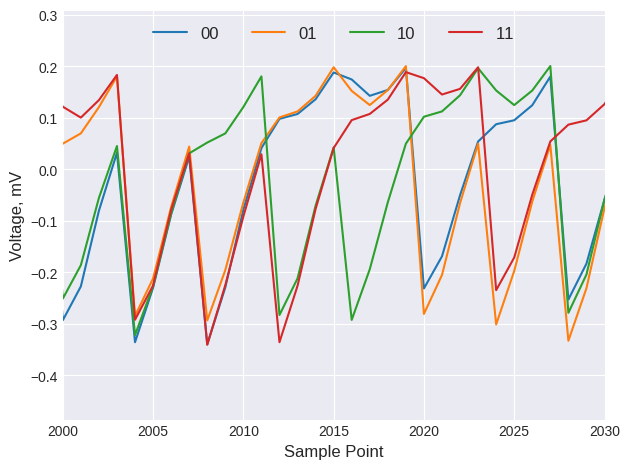

In [61]:

s=2000
e=2030
lw = 1.5
plt.style.use('seaborn-v0_8-darkgrid')

plt.plot(sx0_mean, linewidth=lw, label="00")
plt.plot(sx1_mean, linewidth=lw, label="01")
plt.plot(sx2_mean, linewidth=lw, label="10")
plt.plot(sx3_mean, linewidth=lw, label="11")
plt.xlabel("Sample Point",fontsize=12)
plt.ylabel("Voltage, mV",fontsize=12)
plt.legend(loc='upper center', ncol=4,fontsize=12)
plt.xlim(s,e)  
plt.tight_layout()
plt.savefig("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/results/power_difference_bf1_zoom_2.png",dpi=500)
plt.show()


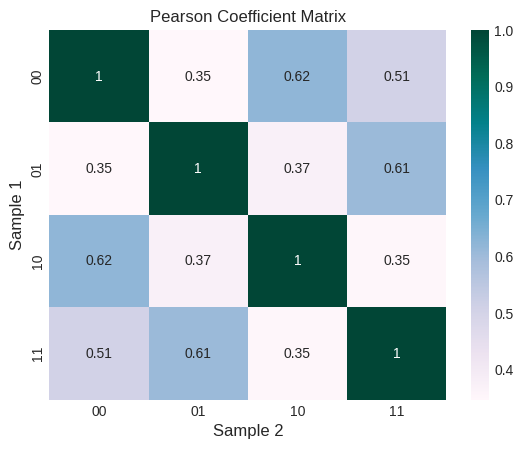

In [59]:
cov_mat = np.zeros([4,4])

for i in range(4):
    for j in range(4):
        pc = stats.pearsonr(means[i], means[j])
        cov_mat[i,j] = pc[0]

class_labels = ["00", "01", "10", "11"]
ax = sns.heatmap(cov_mat, annot=True, cmap="PuBuGn",
                 xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Sample 2',fontsize=12)
plt.ylabel('Sample 1',fontsize=12)
plt.title('Pearson Coefficient Matrix',fontsize=12)
plt.savefig("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/results/pearson_matrix",dpi=500)
plt.show()

In [30]:
tools.plot_overlay(means)

:Overlay
   .Curve.I   :Curve   [x]   (y)
   .Curve.II  :Curve   [x]   (y)
   .Curve.III :Curve   [x]   (y)
   .Curve.IV  :Curve   [x]   (y)
   .Curve.V   :Curve   [x]   (y)

In [24]:
s0s1 = np.abs(sx0_mean - sx1_mean)
s0s2 = np.abs(sx0_mean - sx2_mean)
s0s3 = np.abs(sx0_mean - sx3_mean)

s1s2 = np.abs(sx1_mean - sx2_mean)
s1s3 = np.abs(sx1_mean - sx3_mean)

s2s3 = np.abs(sx2_mean - sx3_mean)


tools.plot_overlay([s0s1, s0s2, s0s3, s1s2, s1s3, s2s3])

:Overlay
   .Curve.I   :Curve   [x]   (y)
   .Curve.II  :Curve   [x]   (y)
   .Curve.III :Curve   [x]   (y)
   .Curve.IV  :Curve   [x]   (y)
   .Curve.V   :Curve   [x]   (y)
   .Curve.VI  :Curve   [x]   (y)
   .Curve.VII :Curve   [x]   (y)

In [ ]:
diff_sum = s0s1 + s0s2 + s0s3 + s1s2 + s1s3 + s2s3
tools.plot_overlay([diff_sum])

Heuristically Chosen points

In [ ]:
points = np.asarray([796, 1040, 1352, 1600, 1784, 2036, 2260, 2460, 2724, 2936])
points = np.arange(0,2999,50)
points = np.array([0,1,2])

In [ ]:
dets = []
invs = []
for i in range(classes):
    compressed_cov = tools.compute_noise_cov_mat(tools.compress_samples(noisey_samples[i*L:(i+1)*L], points), tools.compress_samples(np.reshape(means[i],[1,3]), points))
    det_cov = np.linalg.det(compressed_cov)
    inv_cov = np.linalg.inv(compressed_cov)
    dets.append(det_cov)
    invs.append(inv_cov)
dets = np.asarray(dets)
invs = np.asarray(invs)

In [ ]:
Confusion_matrix, confidence_matrix = tools.class_accuracy_exp(noisey_samples, points, means, dets, invs, L)
class_labels = ["00", "01", "10", "11"]
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
ax = sns.heatmap(Confusion_matrix, annot=True, cmap="PuBuGn",
                 xticklabels=class_labels, yticklabels=class_labels, fmt=".0f")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.subplot(1,2,2)
ax = sns.heatmap(confidence_matrix, annot=True, cmap="PuBuGn",
                 xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confidence Matrix')
plt.tight_layout()
plt.show()